In [3]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt


Set all the Constants (hyper parameters)
are hyperparameters that define key aspects of how the training process will be conducted.
1 BATCH_SIZE:

It represents the number of training examples utilized in one iteration. In simple terms, during each iteration of training, the model updates its weights based on a subset of the entire dataset. The choice of batch size can affect training speed and memory requirements.

2 IMAGE_SIZE:

This typically refers to the dimensions (width and height) of the input images. The neural network architecture and the training process often depend on the size of the input images. It's essential to ensure consistency in image size to feed into the network.

3 CHANNEL:

It represents the number of color channels in the input images. For example, RGB images have three channels (Red, Green, Blue). Grayscale images have one channel. The number of channels influences the

In [4]:
BATCH_SIZE = 32
IMAGE_SIZE = 255
CHANNEL = 3
EPOCHS = 20

import data into tensorflow dataset object
We will use image_dataset_from_directory api to load all images in tensorflow dataset: 1 directory='PlantVillage': This parameter specifies the path to the directory containing your image dataset. In this case, it's assumed that the images are stored in the 'PlantVillage' directory. 2 seed=123:

The seed parameter sets the random seed for data shuffling and transformations. Using a fixed seed ensures reproducibility, meaning that if you run the code with the same seed, you should get the same results. 3 shuffle=True:

The shuffle parameter determines whether to shuffle the data. When set to True, it shuffles the order of the images in each epoch, which is beneficial for training to prevent the model from memorizing the order of the data. 4 image_size=(IMAGE_SIZE, IMAGE_SIZE):

image_size sets the dimensions to which the input images will be resized. The IMAGE_SIZE variable likely holds a specific size, ensuring that all images are standardized to the same dimensions before being fed into the neural network. 5 batch_size=BATCH_SIZE:

The batch_size parameter defines the number of images in each batch during training. It is set to the value of the BATCH_SIZE variable. Training neural networks in batches helps manage memory efficiently and allows for parallel processing, which can speed up training.

In [13]:
dataset = tf.keras.utils.image_dataset_from_directory(
    directory="/content/dataset",
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 900 files belonging to 3 classes.


In [14]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

Below code:


32: The batch size, representing the number of images in the batch.
255: The height of each image.
255: The width of each image.
3: The number of color channels (RGB).

=============================================== single image
This section shows the pixel values of a single image in the batch. It's a 3D tensor representing the color values of each pixel in the image.
Each pixel has three values (RGB) representing the intensity of red, green, and blue, respectively.
The values range from 0 to 255, where 0 is the absence of color, and 255 is the maximum intensity of that color.

=================================================
label
This part shows the labels corresponding to the images in the batch. It's a 1D tensor with a shape of (32), indicating the label for each image in the batch. The labels seem to be integers, ranging from 0 to 2

In [15]:
for image_batch,label_batch in dataset.take(1):
    print("Image Batch Shape : ", image_batch.shape)
    print("Single Image : ", image_batch[0])
    print("Label Image numpy : ", label_batch.numpy)

Image Batch Shape :  (32, 255, 255, 3)
Single Image :  tf.Tensor(
[[[146.89827  134.89827  138.89827 ]
  [117.32479  105.32479  109.32479 ]
  [159.80559  147.80559  151.80559 ]
  ...
  [189.00586  179.00586  178.00586 ]
  [188.99608  178.99608  177.99608 ]
  [188.99413  178.99413  177.99413 ]]

 [[125.09177  113.09177  117.09177 ]
  [153.73062  141.73062  145.73062 ]
  [135.74919  123.74919  127.74919 ]
  ...
  [187.0177   177.0177   176.0177  ]
  [187.01765  177.01765  176.01765 ]
  [186.02547  176.02547  175.02547 ]]

 [[131.32344  119.323456 123.323456]
  [126.39447  114.39447  118.39447 ]
  [143.41678  131.41678  135.41678 ]
  ...
  [190.0195   180.0195   179.0195  ]
  [190.00006  180.00006  179.00006 ]
  [190.       180.       179.      ]]

 ...

 [[133.22902  120.22902  127.22902 ]
  [135.18733  122.18733  129.18733 ]
  [146.90227  133.90227  140.90227 ]
  ...
  [166.02007  156.02007  165.02007 ]
  [160.97076  150.97076  159.97076 ]
  [167.92755  157.92755  166.92755 ]]

 [[138.9

In [16]:
len(class_names)

3

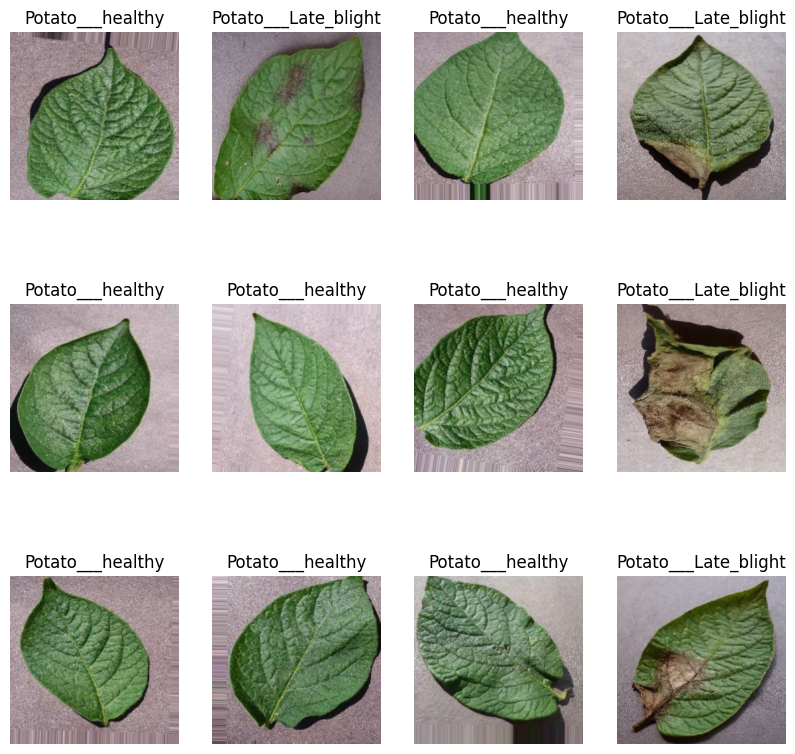

In [19]:
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in dataset.take(1):
    # Code to process the first batch of images and labels
    for i in range(12):
        ax = plt.subplot(3, 4, i +1  )
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

Function to Split Dataset
Dataset should be bifurcated into 3 subsets, namely:

Training: Dataset to be used while training
Validation: Dataset to be tested against while training
Test: Dataset to be tested against after we trained a model

In [20]:
len(dataset)

29

In [21]:
train_size = 0.8
len(dataset) * train_size

23.200000000000003

In [22]:
train_ds = dataset.take(23)
len(train_ds)

23

In [23]:
test_ds = dataset.skip(23)
len(test_ds)

6

In [24]:
val_size = 0.1
len(dataset)*val_size

2.9000000000000004

In [25]:
val_ds = test_ds.take(6)
len(val_ds)

6

In [26]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1

    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [27]:
len(test_ds)

4

In [28]:
len(train_ds)

23

In [29]:
len(val_ds)

2

Cache, Shuffle, and Prefetch the Dataset
additional transformations is commonly used in TensorFlow to optimize the performance of the input pipeline when training machine learning models


In [30]:

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

Building the Model
Creating a Layer for Resizing and Normalization Before we feed our images to network, we should be resizing it to the desired size. Moreover, to improve model performance, we should normalize the image pixel value (keeping them in range 0 and 1 by dividing by 256). This should happen while training as well as inference. Hence we can add that as a layer in our Sequential Model.

You might be thinking why do we need to resize (256,256) image to again (256,256). You are right we don't need to but this will be useful when we are done with the training and start using the model for predictions. At that time somone can supply an image that is not (256,256) and this layer will resize it

In [31]:
resize_and_rescale = tf.keras.Sequential([
  layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
  layers.Rescaling(1./255),
])

Data Augmentation
Data Augmentation is needed when we have less data, this boosts the accuracy of our model by augmenting the data.

In [38]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [39]:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

# Model Architecture

In [40]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNEL)
n_classes = 3

model = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.build(input_shape=input_shape)

In [41]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 255, 255, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (32, 253, 253, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (32, 126, 126, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (32, 124, 124, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [46]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.keras",          # or "best_model.h5"
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [47]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 795ms/step - accuracy: 0.3357 - loss: 1.0983
Epoch 1: val_loss improved from None to 1.08936, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 25s 839ms/step - accuracy: 0.3390 - loss: 1.0991 - val_accuracy: 0.5781 - val_loss: 1.0894
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 728ms/step - accuracy: 0.5270 - loss: 1.0310
Epoch 2: val_loss improved from 1.08936 to 0.62227, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 739ms/step - accuracy: 0.5734 - loss: 0.9223 - val_accuracy: 0.7188 - val_loss: 0.6223
Epoch 3/50
22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 739ms/step - accuracy: 0.6615 - loss: 0.6660
Epoch 3: val_loss improved from 0.62227 to 0.55098, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 721ms/step - accuracy: 0.6737 - loss: 0.6373 - val_accuracy: 0.8594

In [48]:
scores = model.evaluate(test_ds)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9453 - loss: 0.1123


In [49]:
model.save("model.h5")

## Plotting the Accuracy and Loss Curves

In [50]:
print(history)
print(history.params)
print(history.history.keys())

{'verbose': 1, 'epochs': 50, 'steps': 23}
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [51]:
history.history['loss'][:5] # show loss for first 5 epochs

[1.0991215705871582,
 0.9223104119300842,
 0.6372820138931274,
 0.5624703168869019,
 0.38899195194244385]

In [63]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

ValueError: x and y must have same first dimension, but have shapes (20,) and (31,)

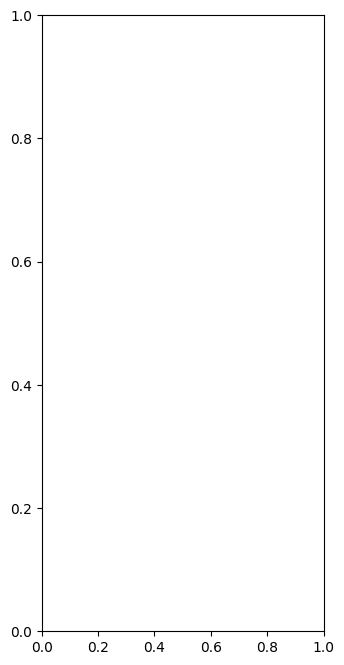

In [53]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### Run prediction on a sample image

In [54]:
model = tf.keras.models.load_model('model.h5')

first image to predict
actual label: Potato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
predicted label: Potato___Early_blight


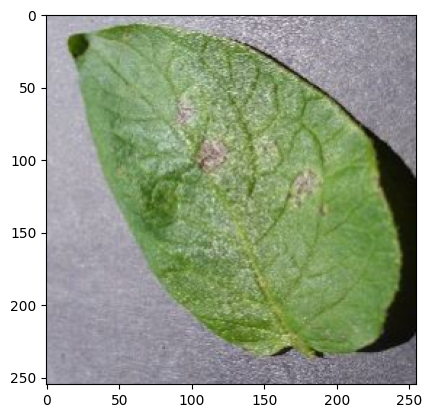

In [60]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):

    first_image = images_batch[3].numpy().astype('uint8')
    first_label = labels_batch[3].numpy()

    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])

    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

# Write a function for inference

In [61]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


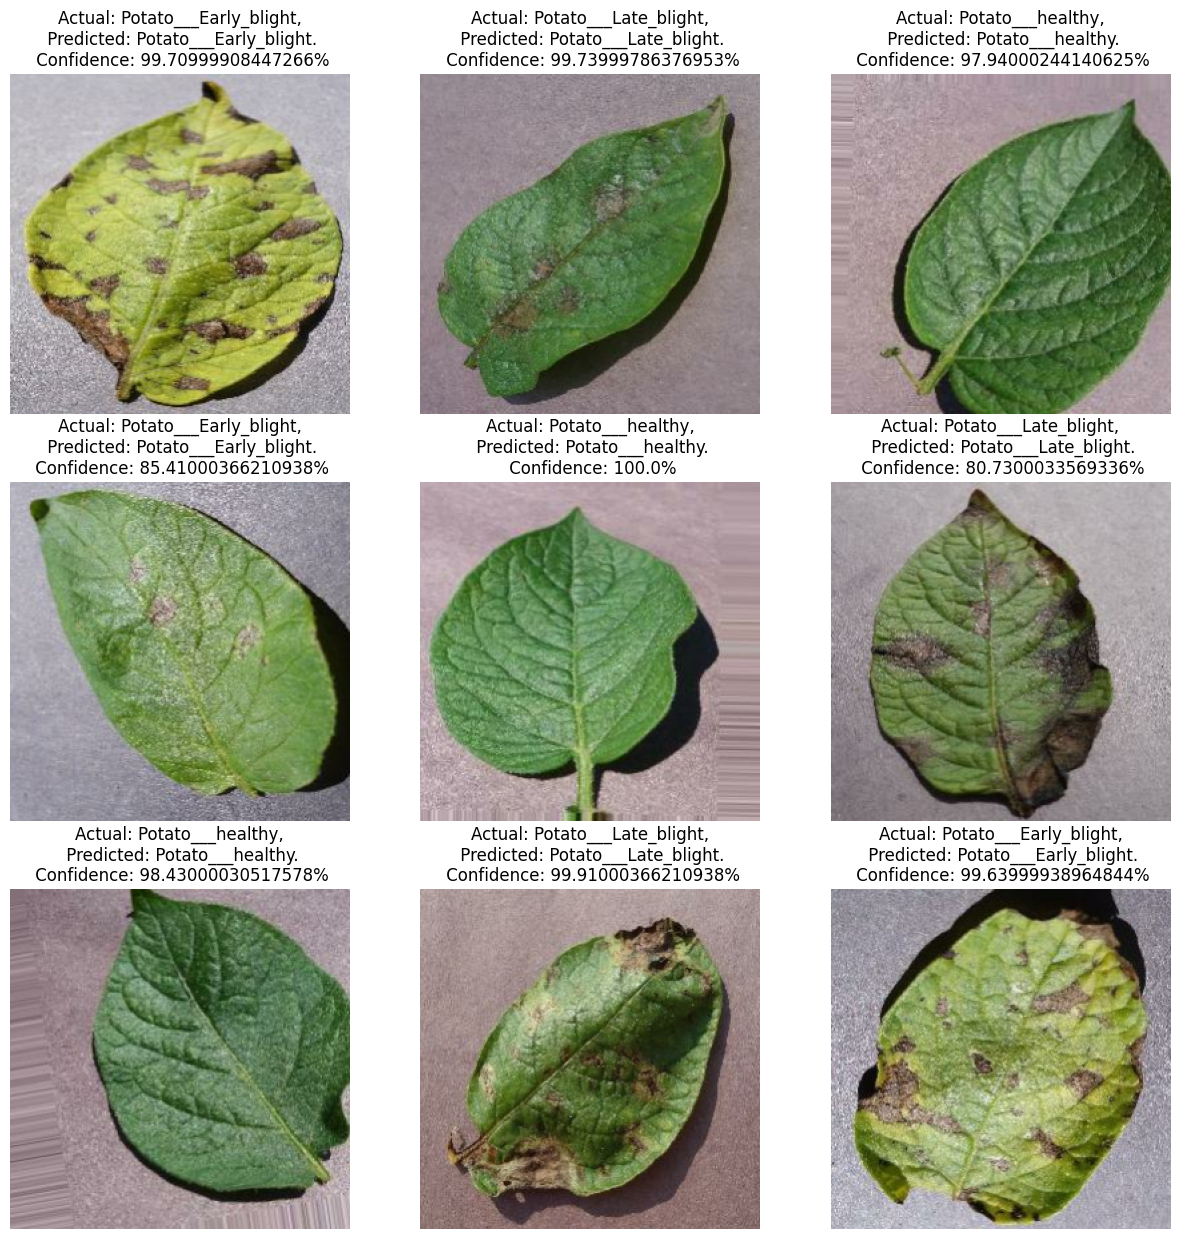

In [62]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")

        plt.axis("off")

In [65]:
best_epoch = history.history['val_accuracy'].index(max(history.history['val_accuracy'])) + 1

print("Best Epoch:", best_epoch)
print(f"Best Validation Accuracy: {history.history['val_accuracy'][best_epoch-1] * 100:.2f}%")
print(f"Training Accuracy at Best Epoch: {history.history['accuracy'][best_epoch-1] * 100:.2f}%")

Best Epoch: 26
Best Validation Accuracy: 98.44%
Training Accuracy at Best Epoch: 95.76%


In [66]:
test_loss, test_acc = model.evaluate(test_ds)

print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9453 - loss: 0.1123
Test Accuracy: 94.53%
Test Loss: 0.1123


In [67]:
model.save("potato_disease_model.h5")

In [68]:
from tensorflow.keras.models import load_model

model = load_model("potato_disease_model.h5")

In [70]:
from tensorflow.keras.models import load_model

models = [
    "best_model.keras",
    "model.h5",
    "potato_disease_model.h5"
]

for model_path in models:
    model = load_model(model_path)

    val_loss, val_acc = model.evaluate(val_ds, verbose=0)
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)

    print(f"\nModel: {model_path}")
    print(f"Validation Accuracy: {val_acc * 100:.2f}%")
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Test Accuracy: {test_acc * 100:.2f}%")
    print(f"Test Loss: {test_loss:.4f}")


Model: best_model.keras
Validation Accuracy: 98.44%
Validation Loss: 0.0934
Test Accuracy: 94.53%
Test Loss: 0.1123

Model: model.h5
Validation Accuracy: 98.44%
Validation Loss: 0.0934
Test Accuracy: 94.53%
Test Loss: 0.1123



Model: potato_disease_model.h5
Validation Accuracy: 98.44%
Validation Loss: 0.0934
Test Accuracy: 94.53%
Test Loss: 0.1123
